#### Stein Variational Gradient Descent
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

# First Step
+ Check Algorithm by simple case
+ Here, we consider about a posterior for mean of multivariate gaussian distribution:
$$
p(w|x^n) \propto p(\mu) \prod_{i=1}^n N(x_i|\mu, I_M)
$$

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

## Data Generation

In [6]:
## dimension of input
M = 2

# number of samples
n = 50

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [26]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

### Calculate gradient of first update
+ Note: In the algorithm, $\sum_i \nabla_{w_i} k(w_i, w_j)$ is necessary, and the result is $L \times M$.

In [29]:
# ite = 0

# post_param = initial_post_param.copy()

# # radial basis kernel is used here
# h = 1
# kernel_post = np.exp(-squareform(pdist(post_param))/(2*h**2))

# dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# # debug
# target = np.zeros((L, M))
# for j in range(L):
#     for k in range(M):
#         target[j,k] = (-post_param[:,k]*kernel_post[:,j] + post_param[j,k]*kernel_post[:,j]).sum() / (h**2)
#         pass

# # gradient of log posterior
# dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# # gradient of target functional
# phi_post_param = (dw_logp + dw_kernel_post) / L

# plt.scatter(post_param[:,0], post_param[:,1])
# plt.show()

# plt.scatter(phi_post_param[:,0], phi_post_param[:,1])
# plt.show()

## Original method
+ Here, we simply use the algorithm

In [32]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

h = 1
for ite in range(n_ite):
    dist = pdist(post_param)
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    # step_size = first_step_size / (ite + 1)
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}".format(ite, post_param[0], h))
    pass

ite = 0, post_param = [-13.05437764  12.43919658], h = 1
ite = 100, post_param = [-7.07524875  6.80888715], h = 1
ite = 200, post_param = [-7.11428592  6.82329473], h = 1
ite = 300, post_param = [-6.97868498  6.6610746 ], h = 1
ite = 400, post_param = [-7.37870938  7.07321988], h = 1
ite = 500, post_param = [-5.77416081  5.36684667], h = 1
ite = 600, post_param = [-4.26922654  3.75245702], h = 1
ite = 700, post_param = [-5.02430997  4.62314027], h = 1
ite = 800, post_param = [-4.35402727  3.88860974], h = 1
ite = 900, post_param = [-5.72944165  5.3554789 ], h = 1
ite = 1000, post_param = [-7.26006357  7.12967851], h = 1
ite = 1100, post_param = [-7.40732341  7.29783141], h = 1
ite = 1200, post_param = [-7.34275847  7.26871492], h = 1
ite = 1300, post_param = [-7.7374924   7.62233958], h = 1
ite = 1400, post_param = [-8.71990243  8.69181973], h = 1
ite = 1500, post_param = [-7.78356287  7.64153128], h = 1
ite = 1600, post_param = [-5.41825356  5.05484698], h = 1
ite = 1700, post_param =

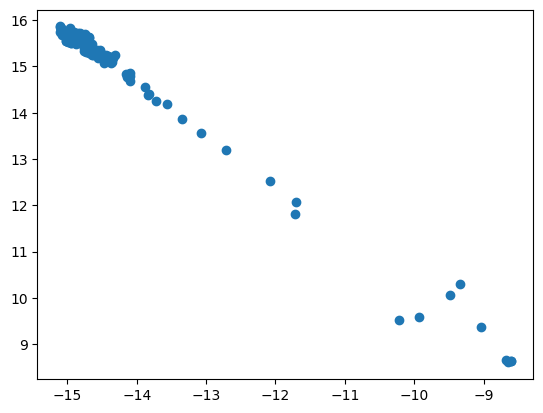

In [34]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

## Plus RMSProp
+ We utilize the RMSProp to adjust step size of the functional gradient

In [37]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, eta_t = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.57252822], h = 0.5536466526065975, eta_t = [0.00064051 0.00059574]
ite = 100, post_param = [-5.28694597  4.15565149], h = 0.5424972821229249, eta_t = [0.00121221 0.00106653]
ite = 200, post_param = [-9.26919431  8.36740954], h = 0.4366975558244395, eta_t = [0.0082884  0.00507044]
ite = 300, post_param = [-9.65830137  9.77411978], h = 0.001994300675533171, eta_t = [1.43217715 0.5582003 ]
ite = 400, post_param = [-9.63317421  9.7616417 ], h = 0.014047765079913184, eta_t = [3.89093419 4.04230596]
ite = 500, post_param = [-9.65971112  9.77970742], h = 0.014530030092175383, eta_t = [4.19737057 3.69973672]
ite = 600, post_param = [-9.68183813  9.78964353], h = 0.013835121799635253, eta_t = [3.75551007 3.48382778]
ite = 700, post_param = [-9.65340202  9.75883399], h = 0.013415741886961187, eta_t = [3.82154934 4.07450044]
ite = 800, post_param = [-9.66638915  9.74943632], h = 0.01465374060384205, eta_t = [3.5167822  3.31444354]
ite = 900, post_param = [-9.

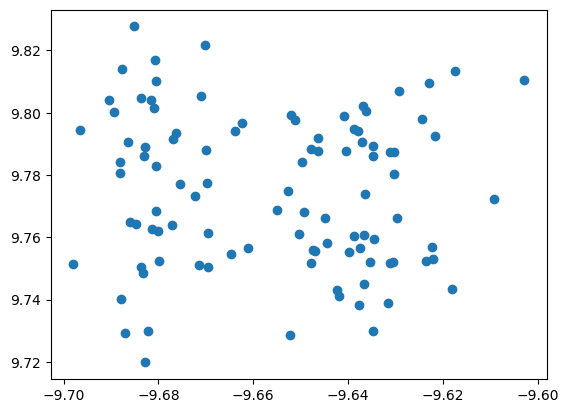

In [39]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

# Next Step: Logistic regression
+ Next we consider about logistic regression
+ Basically, it is same calculation except for derivative of log posterior

In [42]:
from scipy.special import expit

## Data Generation

In [45]:
## dimension of input
M = 5

# number of samples
n = 200

data_seed = 20241229
np.random.seed(data_seed)

true_w = np.random.normal(size=M)

train_X = np.random.normal(size=(n,M))
train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [48]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [51]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_Y[np.newaxis,:]-expit(post_param @ train_X.T))@train_X - pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.67252822 -0.34739504 -1.74420196  0.11277141], h = 0.9732267476637254, step_size = [0.00428812 0.00586958 0.01877046 0.05295068 0.01872544]
ite = 100, post_param = [-2.10123005 -1.67825643 -0.82328005 -0.30603069  0.78946731], h = 0.13119482084764786, step_size = [0.28988293 0.55173601 2.94726893 4.14842775 2.52775539]
ite = 200, post_param = [-1.8867021  -1.54426387 -0.77355179 -0.31653026  0.69413909], h = 0.024950239939852834, step_size = [8.33758637 5.65380675 6.65967979 8.06505676 6.54681828]
ite = 300, post_param = [-1.88438918 -1.56399761 -0.78183051 -0.30998682  0.70010804], h = 0.025391365699121104, step_size = [9.06191369 5.72712865 7.05577084 8.00329519 6.94852747]
ite = 400, post_param = [-1.87727216 -1.54456693 -0.77058817 -0.30135578  0.69126288], h = 0.025816743182777338, step_size = [7.5851128  5.07846503 7.38276858 6.50177968 6.8217543 ]
ite = 500, post_param = [-1.87540612 -1.53970275 -0.77952794 -0.30923578  0.6806435 ], h = 0.02

In [53]:
expit(train_X @ true_w)[:10]

array([0.69784747, 0.59239709, 0.35291562, 0.22766592, 0.53774067,
       0.69643567, 0.29775171, 0.21469685, 0.07502492, 0.0505858 ])

In [55]:
expit(post_param @ train_X.T).mean(axis=0)[:10]

array([0.70519896, 0.66976997, 0.3438697 , 0.23339584, 0.61588581,
       0.69592672, 0.25900725, 0.24858977, 0.05333137, 0.04952232])

In [57]:
true_w

array([-1.69021652, -1.50911208, -0.7582608 , -0.19483659,  0.55051277])

In [59]:
post_param.mean(axis=0)

array([-1.9093922 , -1.5225088 , -0.75738889, -0.33884023,  0.71310634])

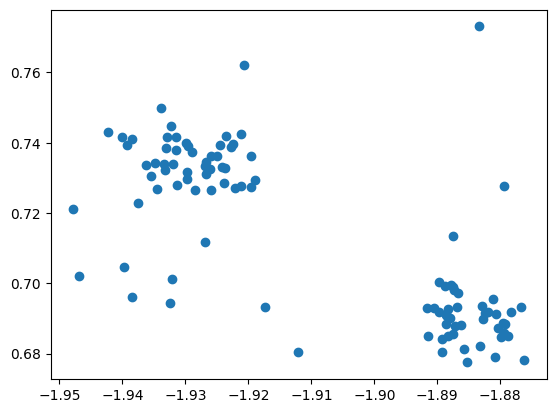

In [61]:
plt.scatter(post_param[:,0], post_param[:,4])
plt.show()

# Next Step: confirm the objective function is optimized
+ Stein Discrepancy $D(q, p)$ is
$$
D(q, p) = E_{w \sim q} [\nabla_w \log p(w)^T \phi(w) + \nabla_w \cdot \phi(w)]
$$
+ $phi(w)$ is obtained by the above alogorithm, and expected value is calculated by the samples from the approximated posterior.
+ Therefore, we can calculate the quantity.
+ Here, we consider about multivariate normal distribution as a target posterior.

## Data Generation

In [65]:
## dimension of input
M = 2

# number of samples
n = 50

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [112]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 2

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

## Original method
+ Here, we simply use the algorithm

In [115]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

h = 1
for ite in range(n_ite):
    dist = pdist(post_param)
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    # step_size = first_step_size / (ite + 1)
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    # # calc stein discrepancy
    # dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    # dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
    
    # # divergence of phi
    # div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    
    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, stein_discrepancy = {}".format(ite, post_param[0], h, stein_discrepancy))
    pass

ite = 0, post_param = [-13.05660199  12.43739082], h = 1, stein_discrepancy = 224496.39637431718
ite = 100, post_param = [-7.17882034  6.93930912], h = 1, stein_discrepancy = 30886.35614275056
ite = 200, post_param = [-7.12757874  6.83698851], h = 1, stein_discrepancy = 26737.603120869095
ite = 300, post_param = [-7.11978018  6.84663657], h = 1, stein_discrepancy = 25010.38244169363
ite = 400, post_param = [-7.01955734  6.65884024], h = 1, stein_discrepancy = 35611.968637510145
ite = 500, post_param = [-7.09341118  6.73625888], h = 1, stein_discrepancy = 28270.422270911156
ite = 600, post_param = [-5.94107274  5.47113608], h = 1, stein_discrepancy = 52326.709359296176
ite = 700, post_param = [-4.3274339   3.64618569], h = 1, stein_discrepancy = 101317.277978218
ite = 800, post_param = [-4.66643313  4.03024681], h = 1, stein_discrepancy = 82272.77843078393
ite = 900, post_param = [-7.71008729  7.35237927], h = 1, stein_discrepancy = 14771.971648085631


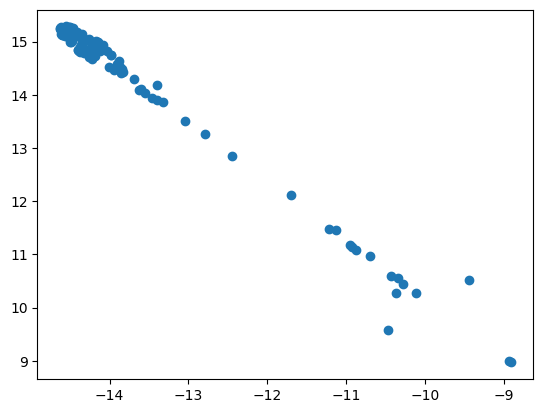

In [117]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [119]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi    
    # # calc stein discrepancy
    # dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    # dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
    # # divergence of phi
    # div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    # dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    # stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, eta_t = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))
    pass

ite = 0, post_param = [-0.58587376 -0.57252822], h = 0.5536466526065975, eta_t = [0.00064028 0.0005959 ], stein_discrepancy = 67843.46362311955
ite = 100, post_param = [-5.29112798  4.1591469 ], h = 0.5428398273245821, eta_t = [0.00120147 0.00105917], stein_discrepancy = 17723.734851037105
ite = 200, post_param = [-9.31431234  8.39696765], h = 0.4457073926604121, eta_t = [0.00772773 0.00481831], stein_discrepancy = 520.5363917748409
ite = 300, post_param = [-9.75390273  9.8700773 ], h = 0.0024107270619031862, eta_t = [1.30131739 0.50687066], stein_discrepancy = 3446.2057858217477
ite = 400, post_param = [-9.71381936  9.84965151], h = 0.01567588987669835, eta_t = [4.46079491 3.56093706], stein_discrepancy = 87.45606232306663
ite = 500, post_param = [-9.78032383  9.85572685], h = 0.013180505065555606, eta_t = [3.9463908  4.16576459], stein_discrepancy = 118.3642902444674
ite = 600, post_param = [-9.78922373  9.86090487], h = 0.016228011070307805, eta_t = [3.89801829 3.86557847], stein_di

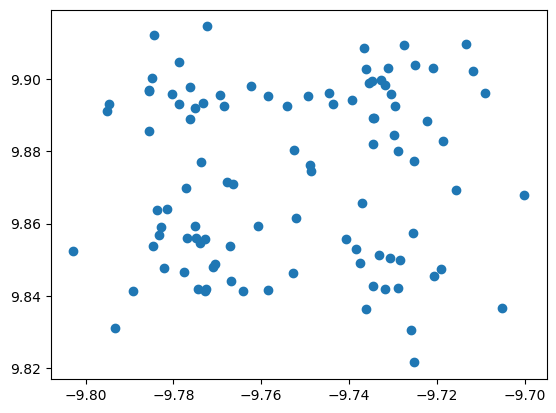

In [121]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

# Next Step: Singular model
+ As a test case of sigular model, we consider about the following model:
$$
p(y|x,a,b) = N(y|a \tanh(bx), 1)
$$
+ When $a=0$ or $b=0$, the model is singular.

## Data Generation

In [69]:
## dimension of input
M = 1

# number of samples
n = 200

data_seed = 20241229
np.random.seed(data_seed)

true_a = 1 #np.random.normal(size=1)
true_b = 1 #np.random.normal(size=1)

train_X = np.random.normal(size=(n,M))
train_Y = true_a * np.tanh(true_b * train_X) + 0.1 * np.random.normal(size=(n,1))
# train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N((a,b)|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times 2}$, $L$ is the number of sample from the approximated posterior

In [72]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 0.1

L = 100
initial_post_param = np.random.normal(size = (L, 2))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [75]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    proc_train_X = train_X.squeeze()[:,np.newaxis]
    proc_train_Y = train_Y.squeeze()[:,np.newaxis]
    residual = proc_train_Y - post_param[:,0][np.newaxis,:] * np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X)
    dw_logpy = np.array([
        (residual * (np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X))).sum(axis=0),
        (residual * (post_param[:,0][np.newaxis,:] * proc_train_X / np.cosh(post_param[:,1][np.newaxis,:] * proc_train_X)**2)).sum(axis=0),
    ]).T
    dw_logp = dw_logpy - pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))
    pass

ite = 0, post_param = [-0.58587376 -0.67252822], h = 0.5536466526065975, step_size = [0.01912472 0.01087536], stein_discrepancy = 1160.1698933725734
ite = 100, post_param = [-0.90724408 -1.69708682], h = 0.9944468893782409, step_size = [0.03728082 0.05568608], stein_discrepancy = 9.10645344151167
ite = 200, post_param = [-0.85959216 -1.99682914], h = 1.2793260696039328, step_size = [0.03232345 0.02564005], stein_discrepancy = 29.068777261945915
ite = 300, post_param = [-0.84482566 -2.15999794], h = 1.508959148500136, step_size = [0.02884911 0.0136651 ], stein_discrepancy = 99.3180094142168
ite = 400, post_param = [-0.83931284 -2.2474155 ], h = 1.6786809764990824, step_size = [0.02682007 0.00850998], stein_discrepancy = 280.1836974146699
ite = 500, post_param = [-0.83733754 -2.29873496], h = 1.8270094771643284, step_size = [0.02527521 0.00574461], stein_discrepancy = 669.613003430184
ite = 600, post_param = [-0.83686297 -2.33171296], h = 1.9481558309480842, step_size = [0.02425057 0.004

In [77]:
true_a, true_b

(1, 1)

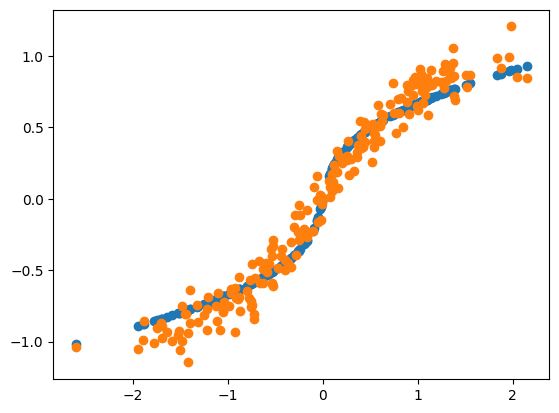

In [79]:
plt.scatter(
    train_X.squeeze(),
    (post_param[:,0][np.newaxis,:] * np.tanh(proc_train_X * post_param[:,1][np.newaxis,:])).mean(axis=1),
)
plt.scatter(
    train_X.squeeze(),
    train_Y.squeeze(),
)
plt.show()

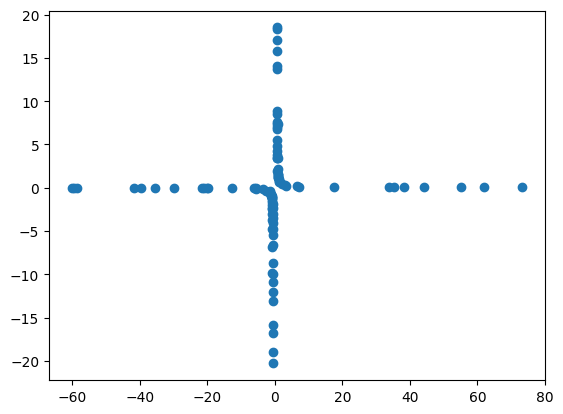

In [81]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [49]:
dist = pdist(post_param)

# radial basis kernel is used here
kernel_post = np.exp(-squareform(dist)/(2*h**2))

# gradient of kernel function
dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# gradient of log posterior
dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# gradient of target functional
phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

In [ ]:
dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))

# divergence of phi
div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()

In [ ]:
dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()

stein_discrepancy = dw_logp_phi + div_phi

In [55]:
stein_discrepancy

10.61485416941364